In [ ]:
!pip install torch_geometric ogb -q

In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import NeighborLoader
from torch_geometric.transforms import ToUndirected
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [6]:
from torch_geometric.data.data import DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import GlobalStorage

torch.serialization.add_safe_globals([DataEdgeAttr, DataTensorAttr, GlobalStorage])

dataset = PygNodePropPredDataset(
    name='ogbn-arxiv',
    root='/kaggle/working/ogb_data',
    transform=ToUndirected()
)

data = dataset[0]
split_idx = dataset.get_idx_split()
data = data.to(device)

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features: {data.num_features}")
print(f"Classes: {dataset.num_classes}")

Nodes: 169343
Edges: 2315598
Features: 128
Classes: 40


In [7]:
import torch
print(torch.__version__)

2.10.0+cu128


In [ ]:
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.10.0+cu128.html -q

In [ ]:
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.10.0+cu128.html -q

In [ ]:
!pip show torch-sparse
!pip show pyg-lib

In [8]:
train_eval_loader = NeighborLoader(
    data,
    num_neighbors=[-1, -1, -1],
    batch_size=4096,
    input_nodes=split_idx['train'],
    shuffle=False
)

val_loader = NeighborLoader(
    data,
    num_neighbors=[-1, -1, -1],
    batch_size=4096,
    input_nodes=split_idx['valid']
)

test_loader = NeighborLoader(
    data,
    num_neighbors=[-1, -1, -1],
    batch_size=4096,
    input_nodes=split_idx['test']
)

train_loader = NeighborLoader(
    data,
    num_neighbors=[-1, -1, -1],
    batch_size=4096,
    input_nodes=split_idx['train'],
    shuffle=True
)

In [9]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.bns   = torch.nn.ModuleList()
        self.dropout = dropout

        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(torch.nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(torch.nn.BatchNorm1d(hidden_channels))

        self.convs.append(SAGEConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

model = GraphSAGE(
    in_channels=data.num_features,
    hidden_channels=256,
    out_channels=dataset.num_classes,
    num_layers=3,
    dropout=0.3
).to(device)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(128, 256, aggr=mean)
    (1): SAGEConv(256, 256, aggr=mean)
    (2): SAGEConv(256, 40, aggr=mean)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
Parameters: 218,664


In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
evaluator = Evaluator(name='ogbn-arxiv')

def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        out = out[:batch.batch_size]
        y   = batch.y[:batch.batch_size].squeeze()
        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(loader, split_key):
    model.eval()
    preds = []
    for batch in loader:
        batch = batch.to(device)
        out  = model(batch.x, batch.edge_index)
        pred = out[:batch.batch_size].argmax(dim=-1, keepdim=True)
        preds.append(pred.cpu())
    preds  = torch.cat(preds, dim=0)
    y_true = data.y[split_idx[split_key]].cpu()
    return evaluator.eval({'y_true': y_true, 'y_pred': preds})['acc']

In [11]:
best_val_acc = 0
save_path = '/kaggle/working/graphsage_best.pt'

for epoch in range(1, 201):
    loss = train()

    if epoch % 10 == 0:
        train_acc = evaluate(train_eval_loader, 'train')
        val_acc   = evaluate(val_loader,   'valid')
        test_acc  = evaluate(test_loader,  'test')

        print(f'Epoch {epoch:03d} | Loss: {loss:.4f} | '
              f'Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'test_acc': test_acc,
            }, save_path)
            print(f'  New best model saved! Val: {val_acc:.4f}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch 010 | Loss: 0.9191 | Train: 0.7391 | Val: 0.7096 | Test: 0.6921
  New best model saved! Val: 0.7096
Epoch 020 | Loss: 0.8041 | Train: 0.7669 | Val: 0.7104 | Test: 0.6867
  New best model saved! Val: 0.7104
Epoch 030 | Loss: 0.7238 | Train: 0.7897 | Val: 0.7144 | Test: 0.6971
  New best model saved! Val: 0.7144
Epoch 040 | Loss: 0.6757 | Train: 0.8132 | Val: 0.7201 | Test: 0.7132
  New best model saved! Val: 0.7201
Epoch 050 | Loss: 0.6320 | Train: 0.8284 | Val: 0.7205 | Test: 0.7052
  New best model saved! Val: 0.7205
Epoch 060 | Loss: 0.6016 | Train: 0.8374 | Val: 0.7129 | Test: 0.6944
Epoch 070 | Loss: 0.5712 | Train: 0.8566 | Val: 0.7220 | Test: 0.7086
  New best model saved! Val: 0.7220
Epoch 080 | Loss: 0.5459 | Train: 0.8628 | Val: 0.7211 | Test: 0.7182
Epoch 090 | Loss: 0.5286 | Train: 0.8769 | Val: 0.7163 | Test: 0.6943
Epoch 100 | Loss: 0.5093 | Train: 0.8837 | Val: 0.7168 | Test: 0.6986
Epoch 110 | Loss: 0.4950 | Train: 0.8883 | Val: 0.7136 | Test: 0.6995
Epoch 120 | Lo

In [12]:
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])

final_test_acc = evaluate(test_loader, 'test')
print(f"Final Test Accuracy: {final_test_acc:.4f}")
print(f"Achieved at epoch: {checkpoint['epoch']}")

Final Test Accuracy: 0.7086
Achieved at epoch: 70


In [13]:
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']}")

Loaded best model from epoch 70


In [14]:
@torch.no_grad()
def get_predictions(loader):
    model.eval()
    preds = []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)
        pred = out[:batch.batch_size].argmax(dim=-1)
        preds.append(pred.cpu())
    return torch.cat(preds, dim=0)

test_preds = get_predictions(test_loader)
test_labels = data.y[split_idx['test']].cpu().squeeze()
print(f"Predictions: {test_preds.shape}, Labels: {test_labels.shape}")

Predictions: torch.Size([48603]), Labels: torch.Size([48603])


In [16]:
import numpy as np

num_classes = dataset.num_classes
per_class_acc = []
for c in range(num_classes):
    mask = test_labels == c
    if mask.sum() > 0:
        acc = (test_preds[mask] == test_labels[mask]).float().mean().item()
        per_class_acc.append((c, acc, mask.sum().item()))

per_class_acc.sort(key=lambda x: x[1], reverse=True)

print("Top 5 classes:")
for c, acc, count in per_class_acc[:5]:
    print(f"  Class {c}: {acc:.4f} ({count} samples)")

print("\nBottom 5 classes:")
for c, acc, count in per_class_acc[-5:]:
    print(f"  Class {c}: {acc:.4f} ({count} samples)")

Top 5 classes:
  Class 16: 0.9216 (10477 samples)
  Class 30: 0.8989 (4631 samples)
  Class 28: 0.8947 (2849 samples)
  Class 14: 0.8310 (71 samples)
  Class 38: 0.7757 (214 samples)

Bottom 5 classes:
  Class 11: 0.1297 (239 samples)
  Class 29: 0.0917 (120 samples)
  Class 21: 0.0392 (51 samples)
  Class 35: 0.0278 (36 samples)
  Class 12: 0.0000 (5 samples)


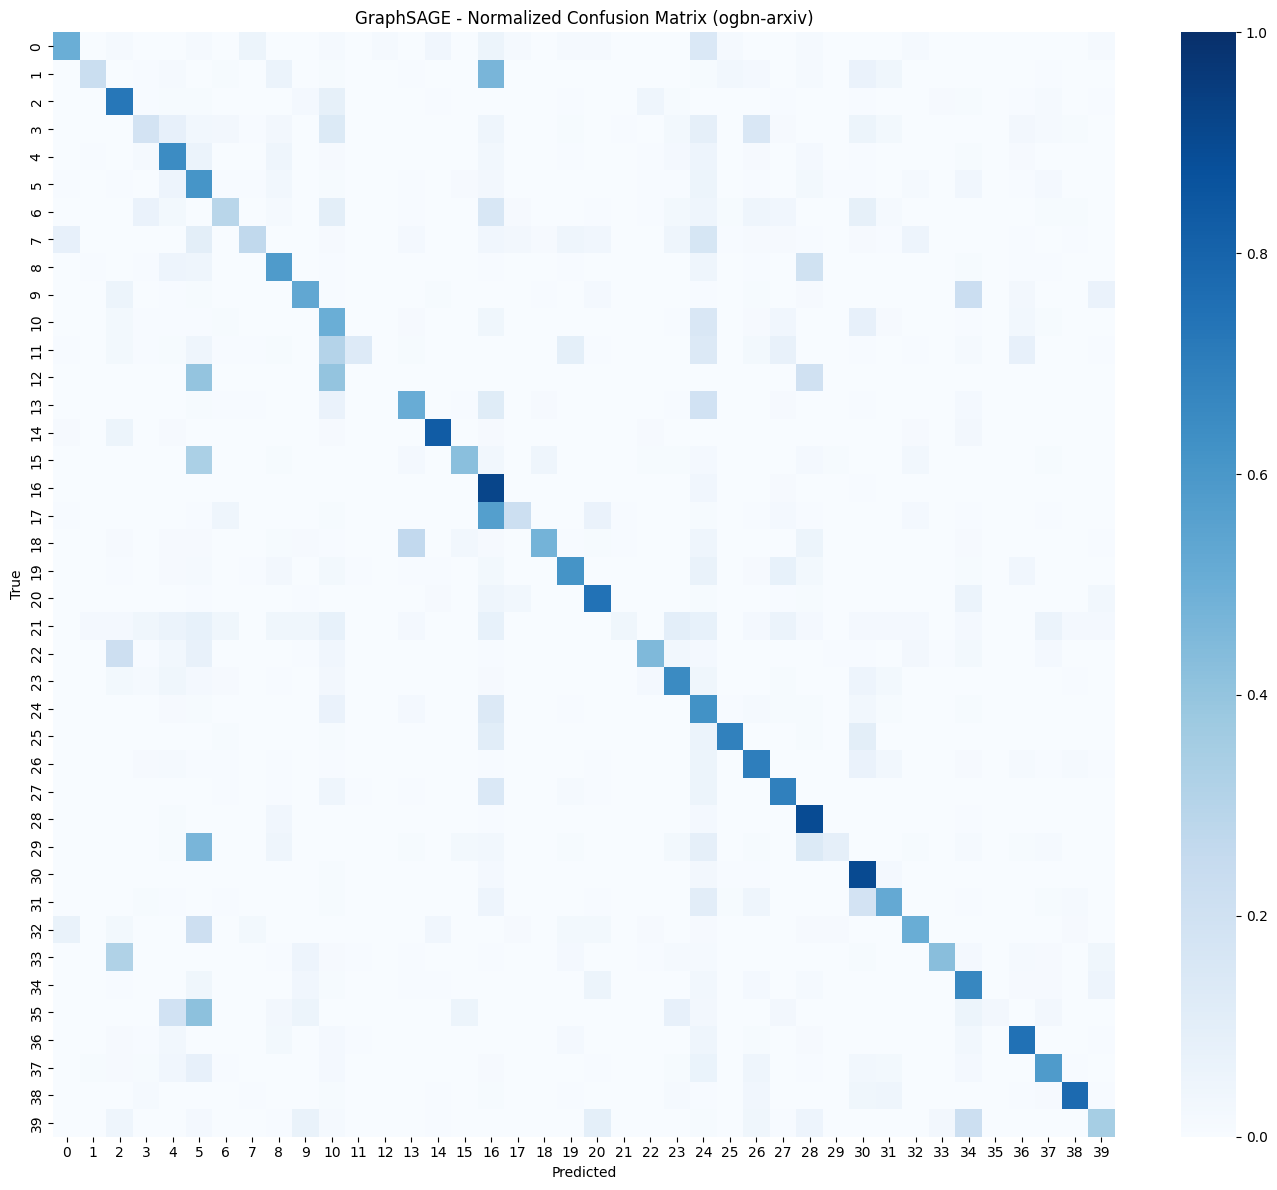

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy())
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_normalized, cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('GraphSAGE - Normalized Confusion Matrix (ogbn-arxiv)')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

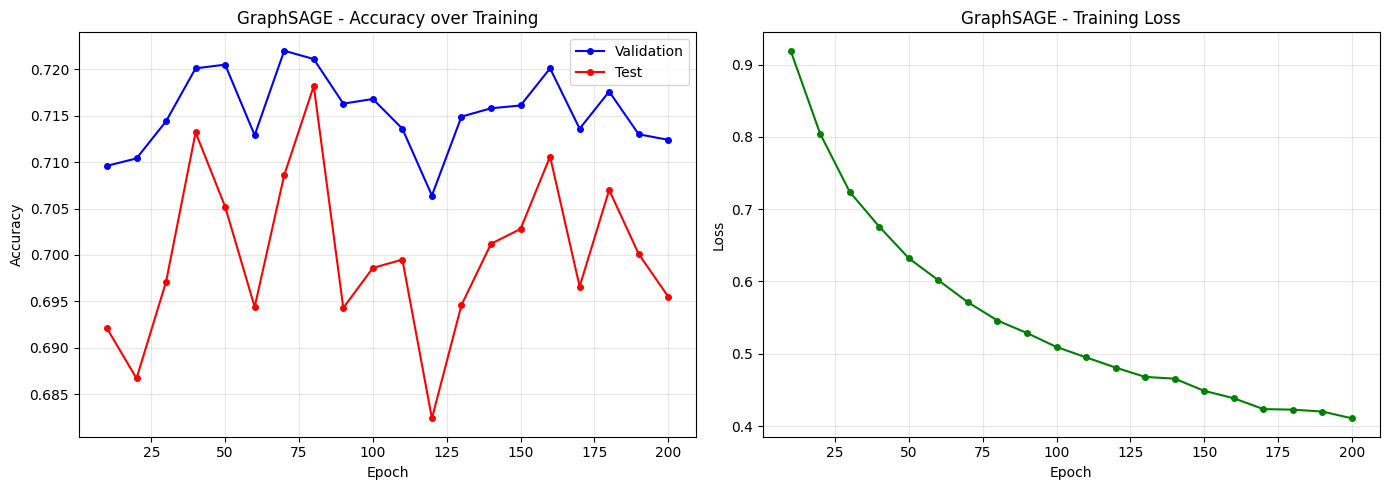

In [18]:
epochs_logged = list(range(10, 201, 10))

val_accs = [0.7096, 0.7104, 0.7144, 0.7201, 0.7205, 0.7129, 0.7220, 0.7211,
              0.7163, 0.7168, 0.7136, 0.7064, 0.7149, 0.7158, 0.7161, 0.7201,
              0.7136, 0.7176, 0.7130, 0.7124]

test_accs = [0.6921, 0.6867, 0.6971, 0.7132, 0.7052, 0.6944, 0.7086, 0.7182,
               0.6943, 0.6986, 0.6995, 0.6824, 0.6946, 0.7012, 0.7028, 0.7106,
               0.6966, 0.7070, 0.7001, 0.6955]

losses = [0.9191, 0.8041, 0.7238, 0.6757, 0.6320, 0.6016, 0.5712, 0.5459,
            0.5286, 0.5093, 0.4950, 0.4808, 0.4679, 0.4655, 0.4486, 0.4384,
            0.4234, 0.4226, 0.4200, 0.4106]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, val_accs, 'b-o', label='Validation', markersize=4)
ax1.plot(epochs_logged, test_accs, 'r-o', label='Test', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('GraphSAGE - Accuracy over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GraphSAGE - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

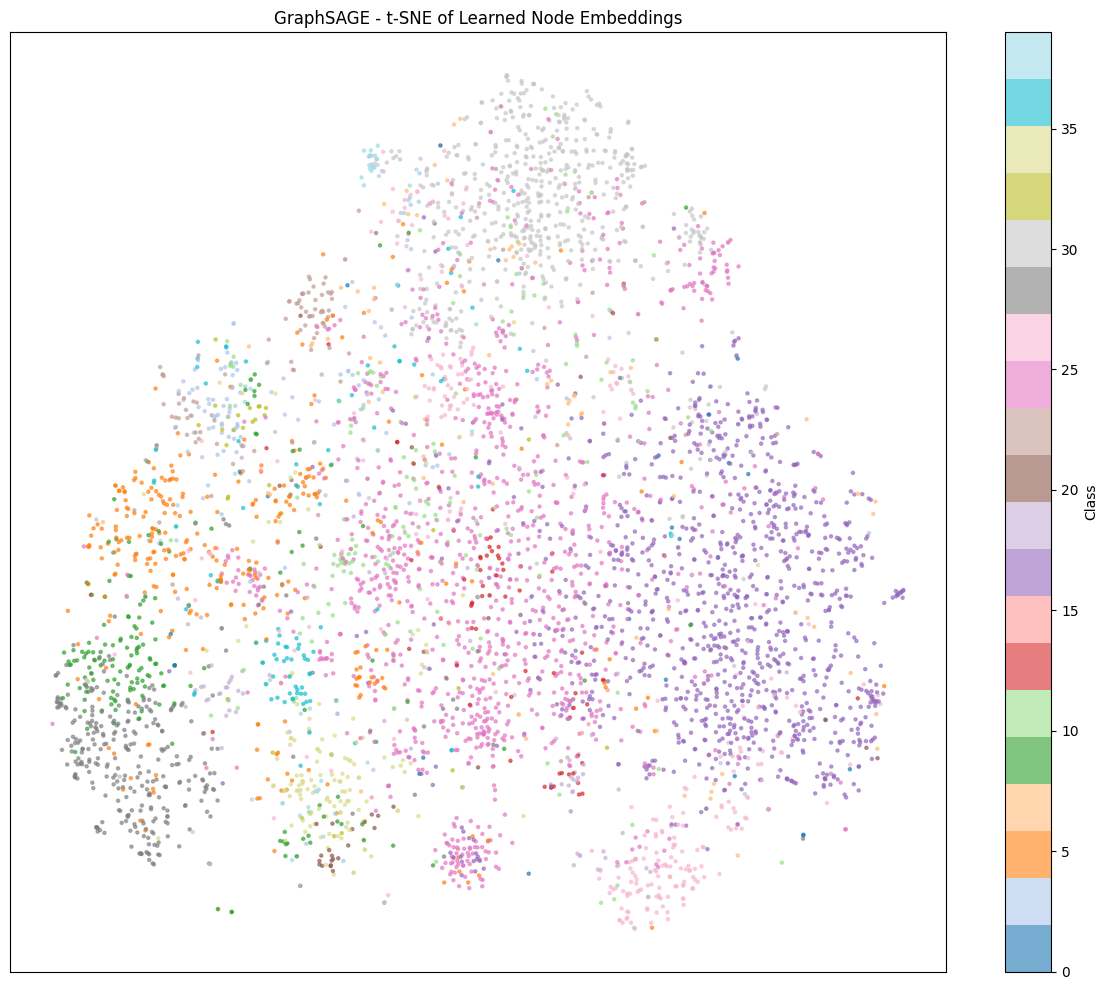

In [19]:
from sklearn.manifold import TSNE

@torch.no_grad()
def get_embeddings(loader):
    model.eval()
    embeds = []
    for batch in loader:
        batch = batch.to(device)
        # Get embeddings before final layer
        x = batch.x
        for i, conv in enumerate(model.convs[:-1]):
            x = conv(x, batch.edge_index)
            x = model.bns[i](x)
            x = F.relu(x)
        embeds.append(x[:batch.batch_size].cpu())
    return torch.cat(embeds, dim=0)

test_embeds = get_embeddings(test_loader)

# Subsample for speed (t-SNE is slow on full dataset)
n_samples = 5000
indices = np.random.choice(len(test_embeds), n_samples, replace=False)
embeds_sub = test_embeds[indices].numpy()
labels_sub = test_labels[indices].numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeds_2d = tsne.fit_transform(embeds_sub)

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(embeds_2d[:, 0], embeds_2d[:, 1], 
                     c=labels_sub, cmap='tab20', s=5, alpha=0.6)
ax.set_title('GraphSAGE - t-SNE of Learned Node Embeddings')
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150)
plt.show()